In [37]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import scipy.stats as st
import itertools
from matplotlib import gridspec
from tqdm import tqdm

from joblib import Parallel, delayed

import sys
sys.path.append('../../code/6_CRM')
from CRM import CRM
from CRM_utils import has_converged


sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [40]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'cs_sweep'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


# run = '20251219-000823'
run = '20260129-111722'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)


run_simulations = False

In [158]:
parsed_data = []

n_cs_arr = data['cs_arr'] 
K_std_arr = data['Kstd_arr'] 
csp_arr = data['csp_arr']
for i in range(args.N):
    N = data[f'N_final_{i}']
    C = data[f'C_{i}']
    n_cs = n_cs_arr[i]
    K_std = K_std_arr[i]
    csp = csp_arr[i]
    
    for j in range(args.iterations):
        richness = np.sum(N[:, j] > 1e-6)
        abundance = list(N[:, j])
        parsed_data.append([i, j, n_cs, K_std, csp, richness]+ abundance)

In [ ]:
df = pd.DataFrame(parsed_data, columns = ['i', 'cs_j', 'n_cs', 'K_std', 'csp', 'richness', 'N1', 'N2', 'N3', 'N4'])

# Identify communities with high and low average richness

In [ ]:
mean_richness = df.groupby('i')['richness'].mean()

In [ ]:
bottom_10 = mean_richness.sort_values().index[:1000]
rich_10 = mean_richness.sort_values().index[-1000:]

In [ ]:
C_bottom = []
C_rich = []

for i in bottom_10:
    C_bottom.append(data[f'C_{i}'])
for i in rich_10:
    C_rich.append(data[f'C_{i}'])

# Niche overlap

In [ ]:
def mean_niche_overlap(C):
    """
    Compute the average niche overlap between species in a community.
    Mean of each pair (divide by union)
    """
    overlaps = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        overlaps_ij = np.sum((ci*cj).astype(bool))/np.sum((ci+cj).astype(bool))
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

def niche_overlap(C):
    """Compute the average niche overlap between species in a community."""
    overlaps = []
    S = C.shape[0]
    Cb = C.astype(bool)
    for i, j in itertools.permutations(range(S), 2):
        ci = Cb[i, :]
        cj = Cb[j, :]
        overlaps_ij = np.sum(ci*cj)/np.sum(ci)
        overlaps.append(overlaps_ij)
    return np.mean(overlaps)

In [ ]:
noi_bottom = []
noi_rich = []
for C in C_bottom:
    noi_bottom.append(niche_overlap(C))
for C in C_rich:
    noi_rich.append(niche_overlap(C))


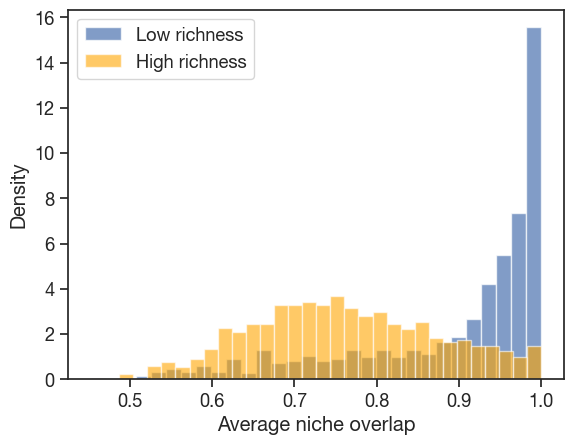

In [ ]:
plt.hist(noi_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(noi_rich, bins=30, alpha=0.6, label='High richness', color='orange', density=True)
plt.xlabel('Average niche overlap')
plt.ylabel('Density')
plt.legend()

In [ ]:
# Euclidean distance in consumption space
def euclidean_distance_C(C):
    """Compute the average Euclidean distance between species in consumption space."""
    distances = []
    S = C.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ci = C[i, :]
        cj = C[j, :]
        dist_ij = np.linalg.norm(ci - cj)
        distances.append(dist_ij)
    return np.mean(distances)

In [ ]:
edc_bottom = []
edc_rich = []
for C in C_bottom:
    edc_bottom.append(euclidean_distance_C(C))
for C in C_rich:
    edc_rich.append(euclidean_distance_C(C))



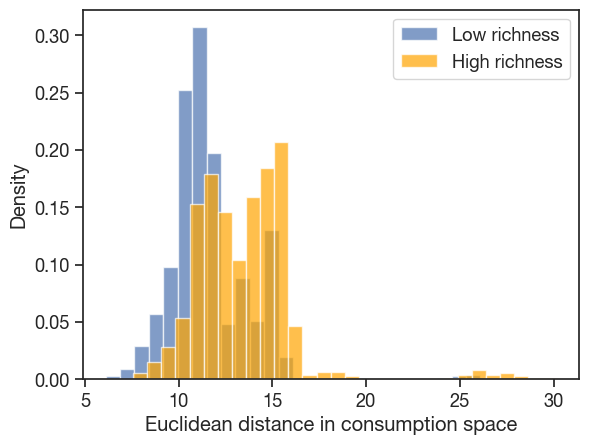

In [ ]:
plt.hist(edc_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(edc_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in consumption space')
plt.ylabel('Density')
plt.legend()

# Private niches


In [ ]:
(C.astype(bool).sum(axis = 0) == 1).sum()

np.int64(0)

In [ ]:
def private_niches(C, fraction=True):
    """Compute the fraction of private niches in a community."""
    if fraction:
        return (C.astype(bool).sum(axis = 0) == 1).sum() / C.shape[1]
    else:
        return (C.astype(bool).sum(axis = 0) == 1).sum()

In [ ]:
pn_bottom = []
pn_rich = []
for C in C_bottom:
    pn_bottom.append(private_niches(C, fraction=True))
for C in C_rich:
    pn_rich.append(private_niches(C, fraction=True))

Text(0, 0.5, 'Density')

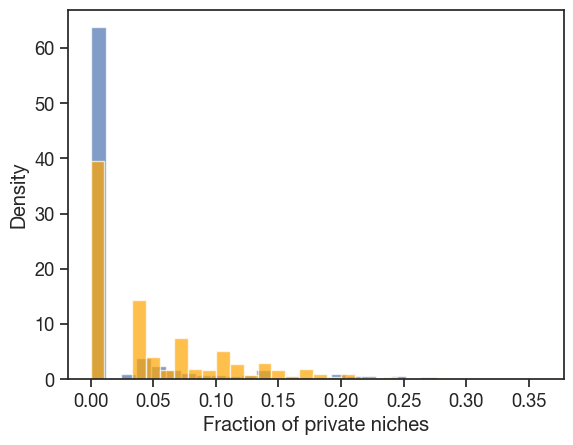

In [ ]:
plt.hist(pn_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(pn_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Fraction of private niches')
plt.ylabel('Density')

# Average Km distance

In [ ]:
def K_log_eucledian_distance(K):
    distances = []
    S = K.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        ki = np.log10(K[i, :])
        kj = np.log10(K[j, :])
        dist_ij = np.linalg.norm(ki - kj)
        distances.append(dist_ij)
    return np.mean(distances)


In [ ]:
ked_bottom = []
ked_rich = []
for i in bottom_10:
    K = data[f'K_{i}']
    ked_bottom.append(K_log_eucledian_distance(K))
for i in rich_10:
    K = data[f'K_{i}']
    ked_rich.append(K_log_eucledian_distance(K))

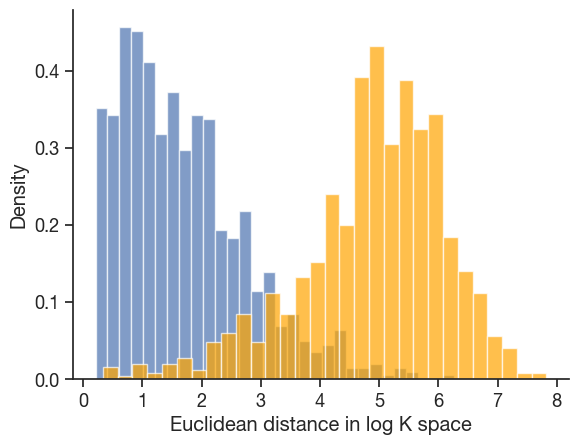

In [ ]:
plt.hist(ked_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ked_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log K space')
plt.ylabel('Density')
sns.despine()

# Log K distance and niche overlap

In [ ]:
len(list(bottom_10) + list(rich_10))

2000

In [ ]:
plot_df = pd.DataFrame(index = list(bottom_10) + list(rich_10))
plot_df['richness'] = list(mean_richness.loc[bottom_10]) + list(mean_richness.loc[rich_10])
plot_df['noi'] = noi_bottom + noi_rich
plot_df['edc'] = edc_bottom + edc_rich
plot_df['ked'] = ked_bottom + ked_rich
plot_df['Category'] = ['Low richness']*len(bottom_10) + ['High richness']*len(rich_10)


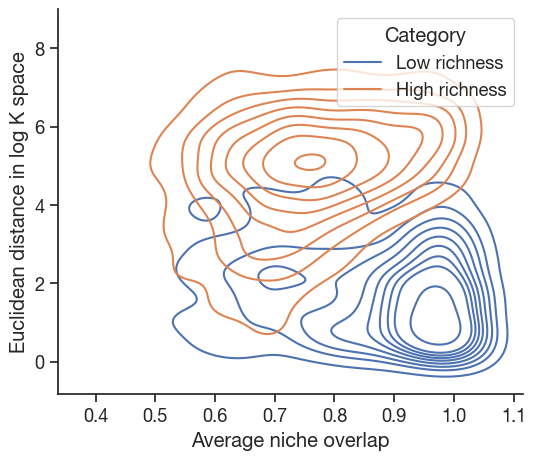

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))
sns.kdeplot(data=plot_df, x='noi', y = 'ked', hue = 'Category')
plt.xlabel('Average niche overlap')
plt.ylabel('Euclidean distance in log K space')
sns.despine()

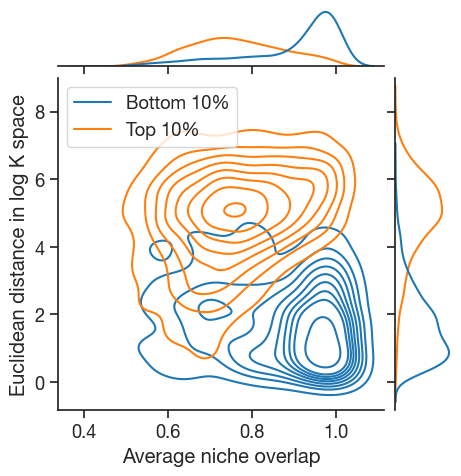

In [ ]:
g = sns.jointplot(data=plot_df, x='noi', y='ked', hue='Category', kind='kde', height=5, palette = 'tab10')#, cut = 0)
g.ax_joint.set_xlabel('Average niche overlap')
g.ax_joint.set_ylabel('Euclidean distance in log K space')
sns.move_legend(g.ax_joint, "upper left", bbox_to_anchor=(0, 1), title='')
# g.ax_joint.set_xlim(.3,1)
# g.ax_joint.set_ylim(0, 8)

# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(g.ax_joint.get_legend().texts, new_labels):
    t.set_text(l) 

plt.savefig(figure_folder / 'community_properties_noi_ked.pdf', dpi=300, bbox_inches='tight')

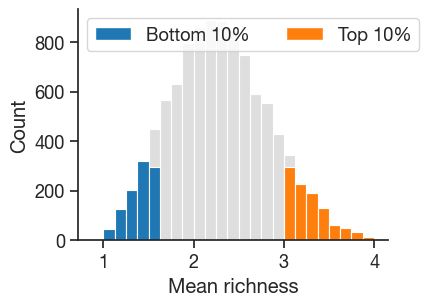

In [ ]:
fig, ax = plt.subplots(figsize=(4,3))

# Calculate bin edges first
bin_edges = np.histogram_bin_edges(mean_richness, bins=25)
g = sns.histplot(mean_richness, ax = ax, bins = bin_edges, color = 'lightgray')
sns.histplot(data=plot_df, x='richness', hue='Category', palette = 'tab10', ax = ax, bins = bin_edges, alpha = 1)
sns.despine()
sns.move_legend(ax, "upper left", bbox_to_anchor=(0, 1), title='', ncol=2)
# Change legende labels
new_labels = ['Bottom 10%', 'Top 10%']
for t, l in zip(ax.get_legend().texts, new_labels):
    t.set_text(l) 
plt.xlabel('Mean richness')
plt.savefig(figure_folder / 'richness_hist.pdf', dpi=300, bbox_inches='tight')

# C/K ratio

In [ ]:
def CK_euclidean_distance(CK_ratio):
    distances = []
    S = CK_ratio.shape[0]
    for i, j in itertools.combinations(range(S), 2):
        cki = np.log10(CK_ratio[i, :])
        ckj = np.log10(CK_ratio[j, :])
        # Replace inf with a small number
        cki = np.where(np.isinf(cki), -3, cki)
        ckj = np.where(np.isinf(ckj), -3, ckj)
        
        dist_ij = np.linalg.norm(cki - ckj)
        distances.append(dist_ij)
    return np.mean(distances)

In [ ]:
np.log10(0)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/135924841.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(0)


np.float64(-inf)

In [ ]:
# Perform cell-by-cell division of C on K
ckd_bottom = []
for i in bottom_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_bottom.append(CK_euclidean_distance(CK_ratio))
ckd_rich = []
for i in rich_10:
    C = data[f'C_{i}']
    K = data[f'K_{i}']
    CK_ratio = C / K
    ckd_rich.append(CK_euclidean_distance(CK_ratio))

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/1167146942.py:5: RuntimeWarning: divide by zero encountered in log10
  cki = np.log10(CK_ratio[i, :])
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/1167146942.py:6: RuntimeWarning: divide by zero encountered in log10
  ckj = np.log10(CK_ratio[j, :])


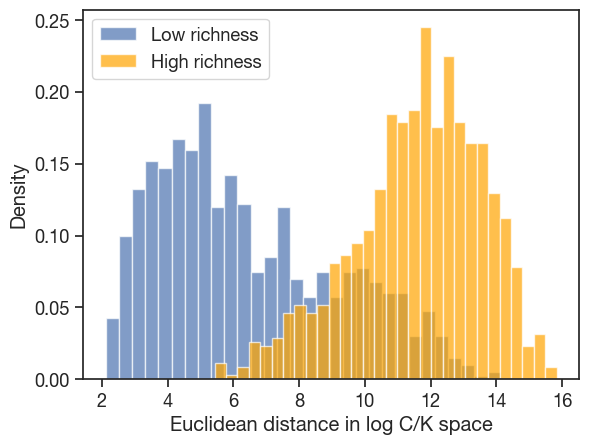

In [ ]:
plt.hist(ckd_bottom, bins=30, alpha=0.7, label='Low richness', color='b', density=True)
plt.hist(ckd_rich, bins=30, alpha=0.7, label='High richness', color='orange', density=True)
plt.xlabel('Euclidean distance in log C/K space')
plt.ylabel('Density')
plt.legend()

In [ ]:
df_mean = df.groupby('i').agg({'richness':('mean', 'std')}).reset_index()

In [ ]:
df_mean.columns = ['i', 'richness_mean', 'richness_std']

In [ ]:
noi_data = []
for i in df_mean['i']:
    noi_data.append(niche_overlap(data[f'C_{i}']))
df_mean['noi'] = noi_data

Text(0, 0.5, 'Average niche overlap')

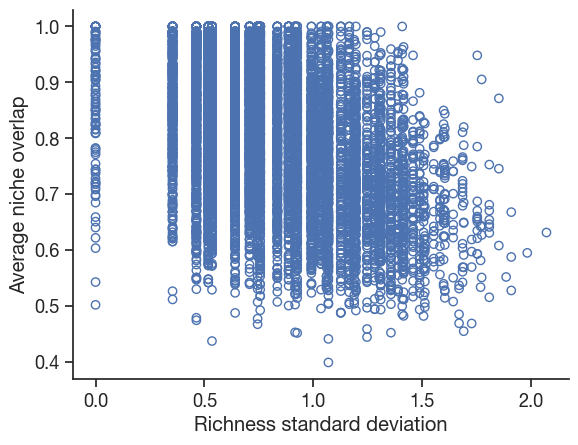

In [ ]:
plt.scatter(df_mean['richness_std'], df_mean['noi'], marker = 'o', facecolor='none', edgecolor='b')
sns.despine()
plt.xlabel('Richness standard deviation')
plt.ylabel('Average niche overlap')

In [ ]:
st.pearsonr(df_mean['richness_std'], df_mean['noi'])

PearsonRResult(statistic=np.float64(-0.4227194639036462), pvalue=np.float64(0.0))

# Monoculture experiments

In [ ]:
indices = list(bottom_10) + list(rich_10)

In [78]:
# if run_simulations:
#     max_time = 200
#     initial_abundance = 1e-3


#     dt = 1
#     method = 'LSODA'
#     initial_c_conc = 10
#     N0 = np.ones(1) * initial_abundance
#     R_min_values = []
#     iterations = 8
#     monoculture_data = []

#     # for i, sdata in enumerate(tqdm(selected_data[::5])):
#     for i in tqdm(indices):
#         n_cs = df.loc[df.i==i, 'n_cs'].values[0]
#         sdata = {'C': data[f'C_{i}'],
#                 'D': data[f'D_{i}'],
#                 'K': data[f'K_{i}']
#         }

#         for j in range(iterations):
#             R0 = np.zeros(n_cs)
#             R0[j] = initial_c_conc
#             C = sdata['C']
#             D = sdata['D']
#             K = sdata['K']
#             l = args.leakage*np.ones(1)

#             for k in range(4):
#                 if C[k,0]<1e-6:
#                     # No growth
#                     continue
#                 c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=1e-3, l=l,  K=K[k, None])
#                 # sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
#                 try:
#                     sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
#                     # muMatrix,kMatrix,dTensor,lVector,delta,Ns,Nr,N0,R0,t_max):
#                     # sol, success = run_lsoda_crossfeeding(C[k, None], K[k, None], D[k, None], l, 0, 1, n_cs, N0, R0, max_time)
#                 except (RuntimeError, ValueError):
#                     print('Error: ', i, k)
#                     monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
#                 else:
#                     N = c.N[-1, :]
#                     R = c.R[-1, :]
#                     monoculture_data.append({'final_abundance': N, 'final_resources': R, 'species_no': k, 'i': i, 'j':j})
#                     # R_min_values.append(np.min(R[-1]))
def run_single_monoculture(i, j, k, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single monoculture simulation"""
    # if C[k, j] < 1e-6:
    #     return None
    
    N0 = np.ones(1) * initial_abundance
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    l = leakage * np.ones(1)
    
    c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
    
    try:
        sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
        N = c.N[-1, :]
        R = c.R[-1, :]
        return {'final_abundance': N, 'final_resources': R, 'species_no': k, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        print('Error: ', i, k)
        return {'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j': j}

if run_simulations:
    max_time = 200
    initial_abundance = 1e-5
    dt = 1
    method = 'LSODA'
    initial_c_conc = 10
    iterations = 8
    
    # Prepare all simulation parameters
    sim_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for k in range(4):
                sim_params.append((i, j, k, C, D, K, n_cs, args.leakage, max_time, 
                                 initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    m_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_monoculture)(*params) for params in sim_params
    )
    
    # Filter out None results
    monoculture_data = [r for r in m_results if r is not None]


In [79]:
fn_mono = results_folder / f'{run}_monocultures.npz'

if run_simulations:
    with open(fn_mono, 'wb') as f:
        np.savez(f, monoculture_data)
else:
    with open(fn_mono, 'rb') as f:
        monoculture_data = np.load(f, allow_pickle=True)['arr_0']

# Spent medium cultivations

In [80]:
# if run_simulations:
#     spent_monoculture_data = []
        
#     for mcdata in tqdm(monoculture_data):
#         if np.isnan(mcdata['final_abundance']) or mcdata['final_abundance'] == initial_abundance:
#             continue
#         if mcdata['final_resources'][0]>0.5*initial_c_conc:
#             # Discard spent media from communities that did not consume most of the primary resource
#             continue
#         i = mcdata['i']
#         j = mcdata['j']
#         k_spent = mcdata['species_no']
#         C = data[f'C_{i}']
#         D = data[f'D_{i}']
#         K = data[f'K_{i}']
#         l = args.leakage * np.ones(1)
#         R0 = mcdata['final_resources']
#         R0[R0<0] = 0
#         N0 = np.ones(1) * initial_abundance
#         n_cs = R0.shape[0]
#         for k in range(4):
#             if k != k_spent:
#                 c = CRM(1, n_cs, C = C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
#                 try:
#                     sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
#                 except (RuntimeError, ValueError):
#                     print('Error: ', i, j, k)
#                     # spent_monoculture_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'species_no': k, 'i': i, 'j':j})
#                 else:
#                     if sol.success:
#                         spent_monoculture_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :], 'spent_medium_from': k_spent, 'species_no': k, 'i': i, 'j':j})
            
def run_single_spent_medium(i, j, k_spent,n_cs, R0, C, D, K, leakage, max_time, initial_abundance, dt, method, initial_c_conc=10):
    """Run a single spent medium simulation"""    

    l = leakage * np.ones(1)
    N0 = np.ones(1) * initial_abundance
    results = []
    for k in range(4):
        if k != k_spent:
            c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
            try:
                sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
                if sol.success:
                    results.append({
                        'final_abundance': c.N[-1, :], 
                        'final_resources': c.R[-1, :], 
                        'spent_medium_from': k_spent, 
                        'species_no': k, 
                        'i': i, 
                        'j': j,
                        'R0': R0[j],
                        't_max': sol.t[-1]
                    })
            except (RuntimeError, ValueError):
                print('Error: ', i, j, k)
    
    return results if results else None

if run_simulations:
    # Prepare data for parallel processing
    sm_params = []
    for mcdata in monoculture_data:
        j = mcdata['j']
        i = mcdata['i']

        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue
    
        
        
        k_spent = mcdata['species_no']

        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources']
        R0[R0<0] = 0
        n_cs = R0.shape[0]

        sm_params.append((i, j,k_spent, n_cs, R0, C, D, K, args.leakage, max_time, initial_abundance, dt, method, initial_c_conc))
    
    


In [81]:
# c = CRM(1, n_cs, C=C[k, None], D=D[k, None], dilution_rate=1e-3, l=l, K=K[k, None])
# sol = c.run(max_time, np.ones(1), R0, dt=dt, method=method, max_calls=1e5)

In [82]:
if run_simulations:
    # Run in parallel
    sm_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_spent_medium)(*params) for params in sm_params
    )

    spent_monoculture_data = [item for r in sm_results if r is not None for item in r]

In [83]:
fn_sm = results_folder / f'{run}_sm_cultures.npz'
if run_simulations:
    with open(fn_sm, 'wb') as f:
        np.savez(f, spent_monoculture_data)
else:
    with open(fn_sm, 'rb') as f:
        spent_monoculture_data = np.load(f, allow_pickle=True)['arr_0']

In [84]:
ijk_to_RO = {}
ijk_to_R = {}
for mc_data in monoculture_data:
    i = mc_data['i']
    j = mc_data['j']
    k = mc_data['species_no']
    if not np.isnan(mc_data['final_abundance']):
        Rj_final = mc_data['final_resources'][j]
    else:
        Rj_final = np.nan
    R = mc_data['final_resources']
    ijk_to_RO[(i,j, k)] = Rj_final
    ijk_to_R[(i,j, k)] = R

In [87]:
SM_df = pd.DataFrame(list(spent_monoculture_data))

In [88]:
SM_df['R0'] = SM_df.apply(lambda row: ijk_to_RO.get((row['i'], row['j'], row['spent_medium_from'])), axis=1)

In [89]:
# Drop rows where the monoculture growth making the spent medium was poor
SM_df = SM_df.loc[SM_df.R0<1]


In [90]:
SM_df['monoculture_abundance'] = [x[0] for x in SM_df['final_abundance']]

In [91]:
SM_df['Category'] = SM_df.i.map(plot_df['Category'].to_dict())

In [92]:
SM_df['log2 FC'] = np.log2(SM_df['monoculture_abundance'] / initial_abundance)


Text(0, 0.5, 'Log2 FC growth in spent medium')

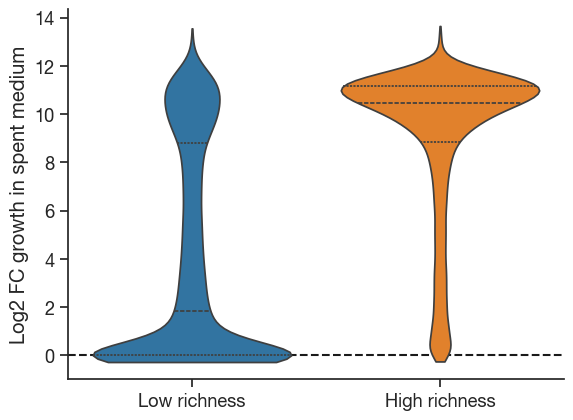

In [134]:
sns.violinplot(SM_df, x = 'Category', y = 'log2 FC', inner = 'quartile', hue = 'Category', palette='tab10', cut = 0)
sns.despine()
plt.xlabel('')
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.ylabel('Log2 FC growth in spent medium')
# plt.yscale('log')

In [136]:
SM_df['log10 Abundance'] = np.log10(SM_df['monoculture_abundance'])

Text(0, 0.5, 'Log2 FC growth in spent medium')

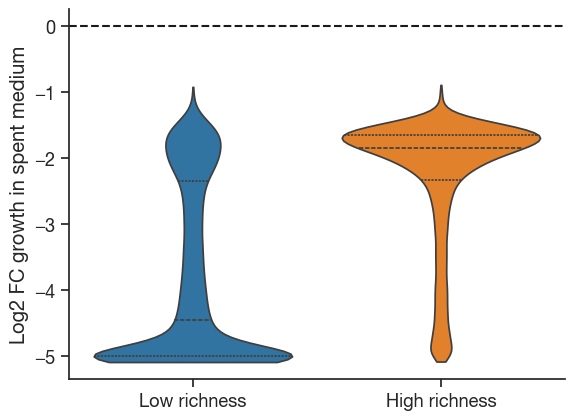

In [137]:
sns.violinplot(SM_df, x = 'Category', y = 'log10 Abundance', inner = 'quartile', hue = 'Category', palette='tab10', cut = 0)
sns.despine()
plt.xlabel('')
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.ylabel('Log2 FC growth in spent medium')
# plt.yscale('log')

# Interactions

## In fresh medium

In [94]:
def run_single_pair_fresh(i, j, pair, C, D, K, n_cs, leakage, max_time, initial_abundance, initial_c_conc, dt, method):
    """Run a single pair culture in fresh medium"""
    R0 = np.zeros(n_cs)
    R0[j] = initial_c_conc
    
    if C[pair, j].min() < 1e-6:
        return None
    
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j}
    except (RuntimeError, ValueError):
        pass
    
    return None

pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    fresh_params = []
    for i in indices:
        n_cs = df.loc[df.i==i, 'n_cs'].values[0]
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        
        for j in range(iterations):
            for pair in pairs:
                fresh_params.append((i, j, pair, C, D, K, n_cs, args.leakage, max_time, 
                                   initial_abundance, initial_c_conc, dt, method))
    
    # Run in parallel
    fresh_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_fresh)(*params) for params in fresh_params
    )
    
    paired_fresh_culture_data = [r for r in fresh_results if r is not None]


In [95]:
fn_inter = results_folder / f'{run}_interactions_fresh.npz'

if run_simulations:
    with open(fn_inter, 'wb') as f:
        np.savez(f, paired_fresh_culture_data)
else:
    with open(fn_inter, 'rb') as f:
        paired_fresh_culture_data = np.load(f, allow_pickle=True)['arr_0']

In [96]:
len(paired_fresh_culture_data)

67990

# In spent medium

In [97]:
def run_single_pair_spent(i, j, k_spent, pair, C, D, K, n_cs, R0, leakage, max_time, initial_abundance, dt, method):
    """Run a single pair culture in spent medium"""
    l = leakage * np.ones(2)
    N0 = np.ones(2) * initial_abundance
    
    c = CRM(2, n_cs, C=C[pair, :], D=D[pair, :], dilution_rate=1e-3, l=l, K=K[pair, :])
    try:
        sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
        if sol.success:
            return {'final_abundance': c.N[-1, :], 'pair': pair, 'i': i, 'j': j, 'spent_medium_from': k_spent}
    except (RuntimeError, ValueError):
        pass
    
    return None

all_pairs = list(itertools.combinations(range(4), 2))
if run_simulations:
    # Prepare parameters for parallel processing
    spent_params = []
    for mcdata in monoculture_data:
        i = mcdata['i']
        j = mcdata['j']
        
        if np.isnan(mcdata['final_abundance']).any() or (mcdata['final_abundance'] == initial_abundance).any():
            continue
        if mcdata['final_resources'][j] > 0.1*initial_c_conc:
            continue

        if j > 2:
            continue

        k_spent = mcdata['species_no']
        C = data[f'C_{i}']
        D = data[f'D_{i}']
        K = data[f'K_{i}']
        R0 = mcdata['final_resources'].copy()
        R0[R0 < 0] = 0
        n_cs = R0.shape[0]
        
        pairs = [p for p in all_pairs if k_spent not in p]
        for pair in pairs:
            spent_params.append((i, j, k_spent, pair, C, D, K, n_cs, R0, args.leakage, max_time, initial_abundance, dt, method))
    
    # Run in parallel
    spent_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(run_single_pair_spent)(*params) for params in spent_params
    )
    
    paired_spent_culture_data = [r for r in spent_results if r is not None]


In [98]:
fn_sm_inter = results_folder / f'{run}_interactions_spent.npz'
if run_simulations:
    with open(fn_sm_inter, 'wb') as f:
        np.savez(f, paired_spent_culture_data)
else:
    with open(fn_sm_inter, 'rb') as f:
        paired_spent_culture_data = np.load(f, allow_pickle=True)['arr_0']

# Compare interactions

In [99]:
M_df = pd.DataFrame(list(monoculture_data))

In [100]:
M_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in M_df['final_abundance']]

In [101]:
M_df.rename(columns={'species_no':'species'}, inplace=True)

In [102]:
M_df.dropna(inplace=True)

In [103]:
# SM_df = pd.DataFrame(spent_monoculture_data)

In [104]:
# SM_df['monoculture_abundance'] = [x if np.isnan(x) else x[0] for x in SM_df['final_abundance']]
SM_df.rename(columns={'species_no':'species'}, inplace=True)

In [105]:
SM_df.dropna(inplace=True)

In [109]:
SIt_df = pd.DataFrame(list(paired_spent_culture_data))

In [110]:
SIt_df[['Species 1', 'Species 2']] = pd.DataFrame(SIt_df.pair.tolist(), index=SIt_df.index)

In [111]:
SIt_df[['Abundance 1', 'Abundance 2']] = pd.DataFrame(SIt_df.final_abundance.tolist(), index=SIt_df.index)

In [112]:
sm_ijk_to_abundance = SM_df.set_index(['i', 'j', 'spent_medium_from', 'species'])['monoculture_abundance'].to_dict()

In [113]:
SIt_df['Spent medium mono abundance 1'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 1'])), axis=1)
SIt_df['Spent medium mono abundance 2'] = SIt_df.apply(lambda row: sm_ijk_to_abundance.get((row['i'], row['j'], row['spent_medium_from'], row['Species 2'])), axis=1)

In [114]:
SIt_df['Interaction 1'] = np.log10(SIt_df['Abundance 1'] / SIt_df['Spent medium mono abundance 1'])
SIt_df['Interaction 2'] = np.log10(SIt_df['Abundance 2'] / SIt_df['Spent medium mono abundance 2'])

In [115]:
SIt_df['Min mono abundance'] = SIt_df[['Spent medium mono abundance 1', 'Spent medium mono abundance 2']].min(axis=1)

In [116]:
SIt_df['Category'] = SIt_df.i.map(plot_df['Category'].to_dict())

In [117]:
SIt_df.columns

Index(['final_abundance', 'pair', 'i', 'j', 'spent_medium_from', 'Species 1',
       'Species 2', 'Abundance 1', 'Abundance 2',
       'Spent medium mono abundance 1', 'Spent medium mono abundance 2',
       'Interaction 1', 'Interaction 2', 'Min mono abundance', 'Category'],
      dtype='object')

In [118]:
SI_df = pd.melt(SIt_df, id_vars = ['i', 'j','spent_medium_from', 'pair', 'Category', 'Min mono abundance', 'Species 1', 'Species 2', 'Abundance 1', 'Abundance 2'], value_vars=['Interaction 1', 'Interaction 2'], value_name='Interaction', var_name = 'Interaction #')

In [119]:

df['Dominant species'] = df[['N1', 'N2', 'N3', 'N4']].idxmax(axis=1).str.strip('N').astype(int)
ij_to_dominant = df.set_index(['i', 'cs_j'])['Dominant species'].to_dict()

In [120]:
SI_df['Dominant'] = SI_df.apply(lambda row: ij_to_dominant[(row['i'], row['j'])], axis=1)

<Axes: ylabel='Interaction'>

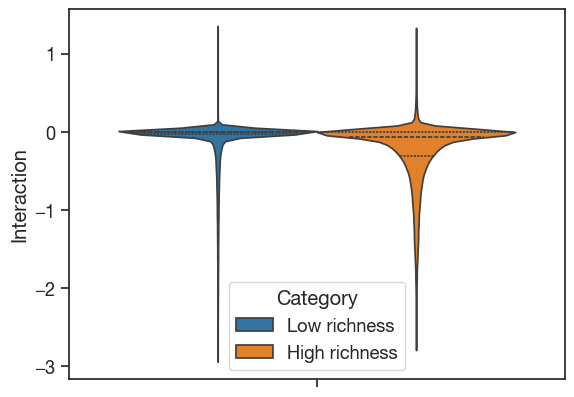

In [127]:
sns.violinplot(SI_df, y = 'Interaction', hue = 'Category', palette='tab10', cut = 0, inner = 'quartile')

In [139]:
SI_df['Min log2 FC'] = np.log2(SI_df['Min mono abundance'] / initial_abundance)

In [144]:
idx = SI_df['Min log2 FC'] > 8 #~SI_df['Min mono abundance'] > 1e-2

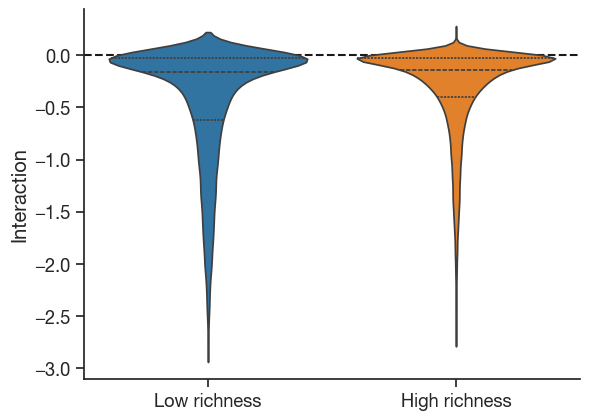

In [145]:
sns.violinplot(SI_df.loc[idx], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('')
sns.despine()

# Compare simulated and measured interactions in spent

In [159]:
measured_interactions_fn = git_folder / 'data' / '5_interactions' / 'all_interactions_cfus_with_stats.csv'
measured_df = pd.read_csv(measured_interactions_fn)

In [162]:
spent_measured = measured_df.loc[measured_df['Fresh'] == 'Spent']

In [ ]:
sns.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/4077914673.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(SI_df.loc[SI_df['Category']=='High richness'], y = 'Interaction', c = 'k', palette='tab10', ax=ax, cut=0, legend = False, label = 'Simulated', common_norm=True)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/4077914673.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(spent_measured, y = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, cut=0, legend = False, label = 'Measured')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/4077914673.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(spent_measured.loc[spent_measured['Focal species'] != 'Ml'], y = 'log10 ratio', palette='tab10', ax=ax, common_norm=False, legend = True)


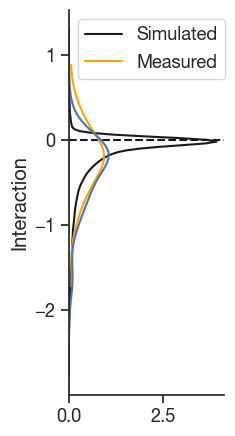

In [181]:
# sns.violinplot(SI_df.loc[SI_df['Category'] == 'High richness'], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
fig, ax = plt.subplots(figsize=(2,5))
sns.kdeplot(SI_df.loc[SI_df['Category']=='High richness'], y = 'Interaction', c = 'k', palette='tab10', ax=ax, cut=0, legend = False, label = 'Simulated', common_norm=True)
sns.kdeplot(spent_measured, y = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, cut=0, legend = False, label = 'Measured')
sns.kdeplot(spent_measured.loc[spent_measured['Focal species'] != 'Ml'], y = 'log10 ratio', palette='tab10', ax=ax, common_norm=False, legend = True)
plt.legend()

plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('')
sns.despine()

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/270726811.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(SI_df.loc[SI_df['Category']=='High richness'], x = 'Interaction', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Simulated (top 10% rich)')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_1465/270726811.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.ecdfplot(spent_measured, x = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, legend = False, label = 'Measured in spent medium')


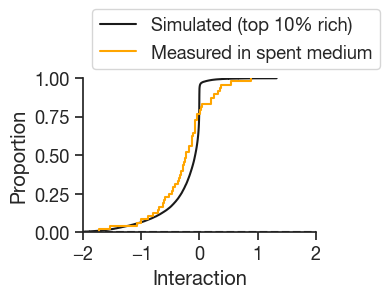

In [209]:
# sns.violinplot(SI_df.loc[SI_df['Category'] == 'High richness'], y = 'Interaction', x = 'Category', hue = 'Category', palette='tab10', cut=0, inner = 'quartile')
fig, ax = plt.subplots(figsize=(3,2))
sns.ecdfplot(SI_df.loc[SI_df['Category']=='High richness'], x = 'Interaction', c = 'k', palette='tab10', ax=ax, legend = False, label = 'Simulated (top 10% rich)')
sns.ecdfplot(spent_measured, x = 'log10 ratio', c = 'orange', palette='tab10', ax=ax, legend = False, label = 'Measured in spent medium')
plt.legend()
sns.move_legend(ax, "lower left", bbox_to_anchor=(0, 1), title='')
ax.set_xlim(-2, 2)
plt.axhline(0, color='k', linestyle='--', zorder = 0)
plt.xlabel('Interaction')
sns.despine()
plt.savefig(figure_folder / 'interaction_comparison.pdf', dpi=300, bbox_inches='tight')

In [146]:
SI_df.loc[idx].groupby('Category')['Interaction'].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
High richness,32314.0,-0.304647,0.413437,-2.791976,-0.395922,-0.138531,-0.028174,0.281121
Low richness,10146.0,-0.422593,0.559512,-2.942360,-0.622066,-0.158378,-0.024014,0.222551


In [125]:
SI_red = SI_df.loc[idx]
SI_red = SI_red.loc[SI_red['Dominant'] == SI_red['spent_medium_from']]

<Axes: ylabel='Interaction'>

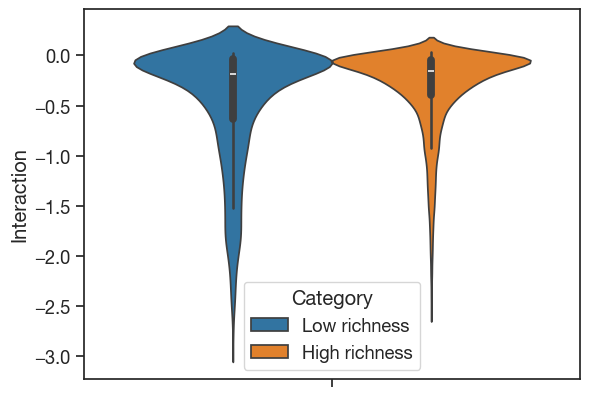

In [ ]:
sns.violinplot(SI_red, y = 'Interaction', hue = 'Category', palette='tab10')


In [ ]:
SI_red.groupby('Category').Interaction.describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
High richness,4144.0,-0.307070,0.397802,-2.501780,-0.395562,-0.159464,-0.041466,0.032162
Low richness,1438.0,-0.442429,0.573944,-2.786863,-0.629749,-0.180737,-0.031325,0.027301


In [ ]:
# Map on i nd j to i and cs_j
richness_dict = df.set_index(['i', 'cs_j'])['richness'].to_dict()
SI_df['Richness'] = SI_df.apply(lambda row: richness_dict[(row['i'], row['j'])], axis=1)

In [ ]:
# Calculate shannon diversity of monoculture abundances in spent medium
from scipy.stats import entropy
def shannon_diversity(abundances):
    abundances = np.array(abundances)
    abundances = abundances[abundances > 0]
    proportions = abundances / np.sum(abundances)
    return entropy(proportions)
df['Shannon'] = df.apply(lambda row: shannon_diversity([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [ ]:
shannon_dict = df.set_index(['i', 'cs_j'])['Shannon'].to_dict()
SI_df['Shannon'] = SI_df.apply(lambda row: shannon_dict[(row['i'], row['j'])], axis=1)

In [ ]:
def shannon(l):
    x_tot = np.sum(l)
    p = l/x_tot
    return -np.sum([pi*np.log(pi) for pi in p])

df['Shannon 2'] = df.apply(lambda row: shannon([row['N1'], row['N2'], row['N3'], row['N4']]), axis=1)

In [ ]:
df

,i,cs_j,n_cs,K_std,csp,richness,N1,N2,N3,N4,Dominant species,Shannon,Shannon 2
0,0,0,29,1.297766,0.214189,2,9.940868e-08,9.999828e-08,9.564276e-01,4.142556e-03,3,0.027794,0.027794
1,0,1,29,1.297766,0.214189,2,9.419840e-01,9.999842e-08,9.998388e-08,3.894045e-02,1,0.166986,0.166986
2,0,2,29,1.297766,0.214189,3,9.994713e-08,4.336320e-02,1.953526e-01,7.067726e-01,4,0.684691,0.684691
3,0,3,29,1.297766,0.214189,3,9.730122e-01,2.300293e-04,9.995734e-08,1.001513e-02,1,0.059042,0.059042
4,0,4,29,1.297766,0.214189,3,4.454022e-03,9.264327e-01,9.979435e-08,3.252208e-02,2,0.176882,0.176882
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,3,22,0.861405,0.257059,2,9.377382e-01,3.217932e-02,9.999607e-08,9.995539e-08,1,0.145623,0.145623
79996,9999,4,22,0.861405,0.257059,1,9.998607e-08,8.538198e-01,9.992303e-08,9.808577e-08,2,0.000006,0.000006
79997,9999,5,22,0.861405,0.257059,2,9.558639e-08,5.184231e-01,3.930953e-01,9.990603e-08,2,0.683668,0.683668
79998,9999,6,22,0.861405,0.257059,2,8.724009e-01,9.891497e-08,9.999032e-08,4.815154e-02,1,0.205257,0.205257


<Axes: ylabel='Shannon'>

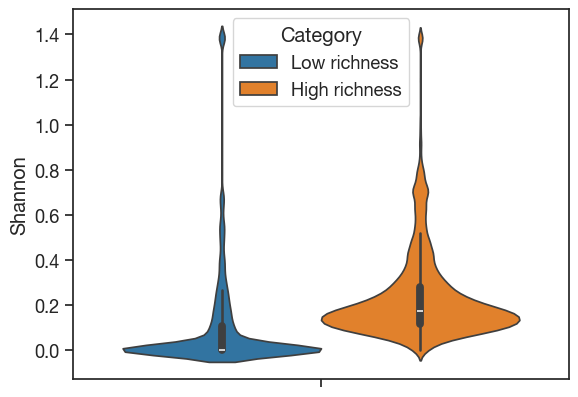

In [ ]:
sns.violinplot(SI_df, y='Shannon', hue='Category', palette='tab10')

# Fresh interactions

In [ ]:
FIt_df = pd.DataFrame(paired_fresh_culture_data)
# SIt_df = pd.DataFrame(paired_spent_culture_data)

In [ ]:
FI_df = FIt_df.explode(column=['final_abundance', 'pair'])


In [ ]:
FI_df.rename(columns={'pair':'species'}, inplace=True)


In [ ]:
FI_df['pair'] = FI_df.index.map(FIt_df['pair'].to_dict())


In [ ]:
FI_df.reset_index(drop=True, inplace=True)


In [ ]:
FI_df['species'] = FI_df['species'].astype(int)

(array([ 1303.,  2938.,  3555.,  4410.,  6391.,  9892., 19095., 11349.,
         7440., 69607.]),
 array([-4.97584432e+00, -4.47826094e+00, -3.98067755e+00, -3.48309417e+00,
        -2.98551078e+00, -2.48792740e+00, -1.99034401e+00, -1.49276063e+00,
        -9.95177246e-01, -4.97593862e-01, -1.04778669e-05]),
 <BarContainer object of 10 artists>)

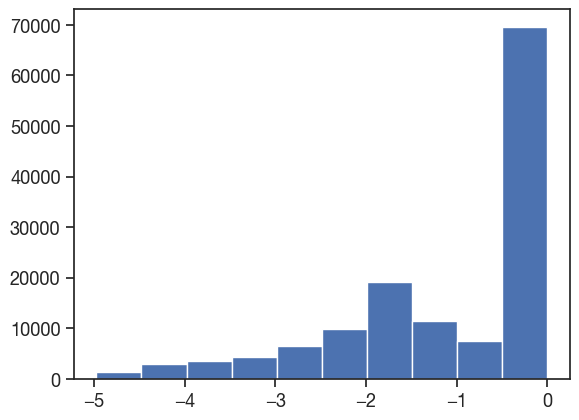

In [ ]:
plt.hist(np.log10(FI_df.final_abundance.astype(float)))
# plt.xscale('log')

In [ ]:
FIM_df = pd.merge(left = FI_df, right = M_df.loc[:, ['monoculture_abundance', 'i', 'j', 'species']], on=['i', 'j', 'species'], how = 'left')
# SIM_df = pd.merge(left = SI_df, right = SM_df.loc[:, ['spent_medium_from', 'species', 'i', 'j', 'monoculture_abundance', 'R0']], how = 'left')

In [ ]:
FIM_df.dropna(inplace=True)
# SIM_df.dropna(inplace = True)

In [ ]:
FIM_df['final_abundance'] = FIM_df['final_abundance'].astype(float)
# SIM_df['final_abundance'] = SIM_df['final_abundance'].astype(float)

In [ ]:
FIM_df['log10 FC'] = np.log10(FIM_df['final_abundance'] / FIM_df['monoculture_abundance'])
# SIM_df['log10 FC'] = np.log2(SIM_df['final_abundance'] / SIM_df['monoculture_abundance'])

In [ ]:
FIM_df['Category'] = FIM_df.i.map(plot_df['Category'].to_dict())
# SIM_df['Category'] = SIM_df.i.map(plot_df['Category'].to_dict())

In [ ]:
FIM_df.loc[FIM_df['log10 FC'] > 0.5]

,final_abundance,species,i,j,pair,monoculture_abundance,log10 FC,Category
5,0.000188,3,1990,0,"(0, 3)",0.000023,0.905653,Low richness
9,0.000199,3,1990,0,"(1, 3)",0.000023,0.931187,Low richness
56,0.017069,1,1990,5,"(1, 3)",0.000769,1.346138,Low richness
102,0.010714,0,7283,2,"(0, 2)",0.002841,0.576547,Low richness
104,0.031020,0,7283,2,"(0, 3)",0.002841,1.038225,Low richness
...,...,...,...,...,...,...,...,...
135922,0.001748,0,7554,2,"(0, 2)",0.000378,0.665161,High richness
135924,0.012963,0,7554,2,"(0, 3)",0.000378,1.535410,High richness
135937,0.016049,3,7554,3,"(0, 3)",0.000577,1.444315,High richness
135941,0.023100,3,7554,3,"(1, 3)",0.000577,1.602468,High richness


# Statistical comparison of log10 FC between categories in SIM_df

In [ ]:
# Statistical tests
from scipy import stats

# Separate data by category
low_richness = SI_df[SI_df['Category'] == 'Low richness']['Interaction'].dropna()
high_richness = SI_df[SI_df['Category'] == 'High richness']['Interaction'].dropna()

# Mann-Whitney U test (non-parametric)
statistic, p_value = stats.mannwhitneyu(low_richness, high_richness, alternative='two-sided')
print(f"Mann-Whitney U test:")
print(f"  Statistic: {statistic:.2f}")
print(f"  P-value: {p_value:.4e}")

# t-test (parametric, for comparison)
t_stat, t_pval = stats.ttest_ind(low_richness, high_richness)
print(f"\nIndependent t-test:")
print(f"  t-statistic: {t_stat:.2f}")
print(f"  P-value: {t_pval:.4e}")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(low_richness)-1)*low_richness.std()**2 + 
                      (len(high_richness)-1)*high_richness.std()**2) / 
                     (len(low_richness) + len(high_richness) - 2))
cohens_d = (low_richness.mean() - high_richness.mean()) / pooled_std
print(f"\nEffect size (Cohen's d): {cohens_d:.3f}")

Mann-Whitney U test:
  Statistic: 1659481656.00
  P-value: 0.0000e+00

Independent t-test:
  t-statistic: 52.28
  P-value: 0.0000e+00

Effect size (Cohen's d): 0.335


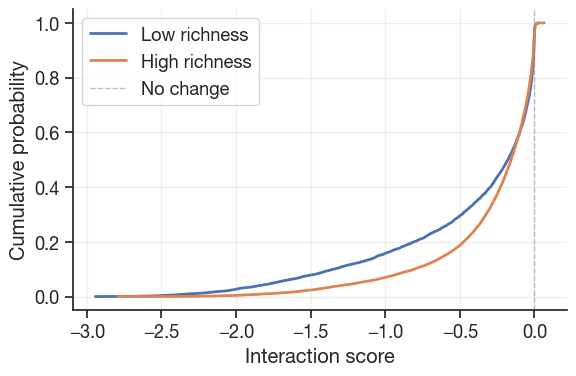

In [ ]:
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
idx = SI_df['Min mono abundance'] > 1e-2
red_df = SI_df.loc[idx]
for category in ['Low richness', 'High richness']:
    data = red_df[red_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()

In [ ]:
SI_df['Max mono abundance'] = SI_df[['Abundance 1', 'Abundance 2']].max(axis=1)


In [ ]:
SI_df

,i,j,spent_medium_from,pair,Category,Min mono abundance,Species 1,Species 2,Abundance 1,Abundance 2,Interaction #,Interaction,Dominant,Richness,Shannon,Max mono abundance
0,1990,0,0,"(1, 2)",Low richness,0.000022,1,2,0.000023,0.002307,Interaction 1,0.008245,1,1,0.000005,0.002307
1,1990,0,0,"(1, 3)",Low richness,0.000022,1,3,0.000022,0.000129,Interaction 1,0.000665,1,1,0.000005,0.000129
2,1990,0,0,"(2, 3)",Low richness,0.000129,2,3,0.002287,0.000119,Interaction 1,-0.004626,1,1,0.000005,0.002287
3,1990,0,1,"(0, 2)",Low richness,0.000028,0,2,0.000125,0.000027,Interaction 1,-0.001457,1,1,0.000005,0.000125
4,1990,0,1,"(0, 3)",Low richness,0.000126,0,3,0.000122,0.000761,Interaction 1,-0.014168,1,1,0.000005,0.000761
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97537,7554,2,2,"(0, 3)",High richness,0.000190,0,3,0.000190,0.000575,Interaction 2,-0.003419,3,4,0.086745,0.000575
97538,7554,2,2,"(1, 3)",High richness,0.000580,1,3,0.006715,0.000365,Interaction 2,-0.200727,3,4,0.086745,0.006715
97539,7554,2,3,"(0, 1)",High richness,0.013402,0,1,0.011943,0.006545,Interaction 2,-0.399123,3,4,0.086745,0.011943
97540,7554,2,3,"(0, 2)",High richness,0.002899,0,2,0.013280,0.000538,Interaction 2,-0.731577,3,4,0.086745,0.013280


<Axes: xlabel='Interaction', ylabel='Density'>

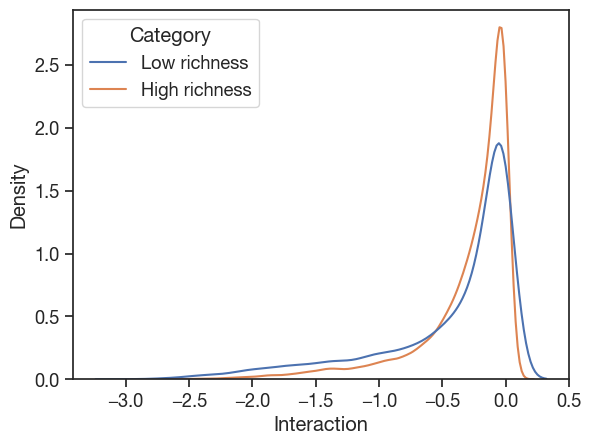

In [ ]:
sns.kdeplot(SI_df.loc[idx], x = 'Interaction', hue = 'Category', common_norm=False)

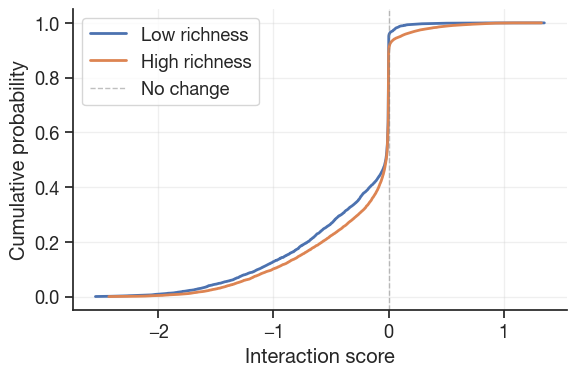

In [ ]:
idx2 = (SI_df['Min mono abundance'] < 1e-2)& (SI_df['Max mono abundance']>1e-2)
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
red_df = SI_df.loc[idx2]
for category in ['Low richness', 'High richness']:
    data = red_df[red_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()

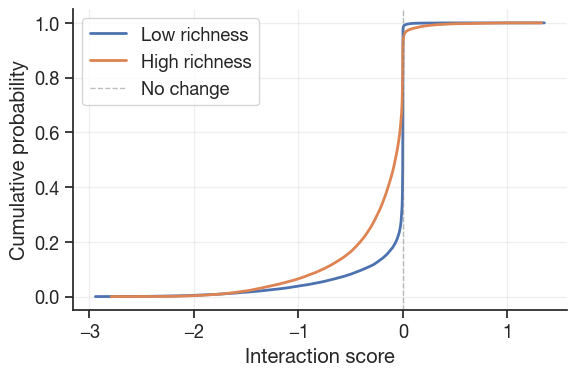

In [ ]:
# Cumulative distribution comparison
fig, ax = plt.subplots(figsize=(6, 4))
for category in ['Low richness', 'High richness']:
    data = SI_df[SI_df['Category'] == category]['Interaction'].dropna()
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cumulative, label=category, linewidth=2)

plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='No change')
plt.xlabel('Interaction score')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()